# RL Trading Arena -- Analysis Notebook

**INTE 42222 - Reinforcement Learning**

This notebook is the *analysis* layer. The submitted agents stay as plain modules
(`IM07_agent_bandit.py`, `IM07_agent_mdp.py`) because `submit_agent.py` reads the
file as source text and `test_locally.py` imports it as a module -- a notebook
cannot be submitted. Everything here imports those modules rather than redefining
them, so what is analysed is exactly what is submitted.

The written argument lives in `report/IM07_REPORT.md`. This notebook produces the
evidence behind it.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Run from the project root regardless of where Jupyter was launched.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), "experiments"))

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
print("cwd:", os.getcwd())

cwd: D:\Lectures\4th year\4.2\INTE 42222 - Reinforcement Learning\Trading_Bot_RL


## 1. Verify the reconstructed kit (gate V0)

The starter kit was reconstructed from the supplied PDFs, so the first thing to
establish is that it reproduces the specification's published baseline scores. If
these do not match, every later number is suspect.

In [2]:
from eval_harness import run_bandit_eval, run_mdp_eval
from baseline_agents import (
    RandomBanditAgent,
    EpsilonGreedyBanditAgent,
    RandomMDPAgent,
    BuyAndHoldMDPAgent,
    QLearningReferenceAgent,
)

expected = {
    "RandomBanditAgent": 0.34,
    "EpsilonGreedyBanditAgent": 0.21,
    "RandomMDPAgent": -0.04,
    "BuyAndHoldMDPAgent": -0.04,
    "QLearningReferenceAgent": 0.03,
}

for cls, runner in [(RandomBanditAgent, run_bandit_eval),
                    (EpsilonGreedyBanditAgent, run_bandit_eval),
                    (RandomMDPAgent, run_mdp_eval),
                    (BuyAndHoldMDPAgent, run_mdp_eval),
                    (QLearningReferenceAgent, run_mdp_eval)]:
    got = runner(cls)["score"]
    print(f"{cls.__name__:26s} spec ~{expected[cls.__name__]:+.2f}   measured {got:+.4f}")

RandomBanditAgent          spec ~+0.34   measured +0.3375


EpsilonGreedyBanditAgent   spec ~+0.21   measured +0.2070


RandomMDPAgent             spec ~-0.04   measured -0.0437


BuyAndHoldMDPAgent         spec ~-0.04   measured -0.0371


QLearningReferenceAgent    spec ~+0.03   measured +0.0279


Note the second row. Fixed epsilon-greedy scores *below* random, which the
specification flags as a good first exercise. The reason is that its sample mean
is a lifetime average: evidence gathered in the bull phase still outvotes evidence
from the bear phase 140 pulls later, so the agent exploits an arm that stopped
being good. Forgetting, not more exploration, is the fix -- and that observation
drives the whole Phase 1 design.

## 2. What is the problem actually worth?

Before choosing an algorithm, measure the ceiling. A score with no ceiling beside
it is uninterpretable -- and as it turns out, the advertised 0.34 random baseline
is not the bar that matters.

In [3]:
from IM07_arm_ev import find_phase_boundaries, measure_arm_ev, ceilings
from bandit_env import STRATEGIES, TradingBanditEnv

env = TradingBanditEnv(total_pulls=200)
boundaries, spans = find_phase_boundaries(env)
print("regime switches at pulls:", boundaries)
for lo, hi, ph in spans:
    print(f"  pulls {lo:3d}-{hi:3d}   phase {ph}   mix {env.PHASE_MIXES[ph]}")

regime switches at pulls: [80, 140]
  pulls   0- 79   phase 0   mix {'bull': 0.85, 'bear': 0.05, 'choppy': 0.1}
  pulls  80-139   phase 1   mix {'bull': 0.05, 'bear': 0.05, 'choppy': 0.9}
  pulls 140-199   phase 2   mix {'bull': 0.05, 'bear': 0.85, 'choppy': 0.1}


In [4]:
# 40,000 samples per (phase, arm) cell -- takes about a minute.
means, stderrs, spans = measure_arm_ev()

print(f"{'phase':<8}" + "".join(f"{s:>16}" for s in STRATEGIES))
for p in range(means.shape[0]):
    print(f"{p:<8}" + "".join(f"{means[p, a]:>+16.4f}" for a in range(means.shape[1])))
print()
print("best arm per phase:", [STRATEGIES[a] for a in means.argmax(axis=1)])

oracle, per_arm = ceilings(means, spans)
print(f"\noracle ceiling         : {oracle:.3f}")
for a, name in enumerate(STRATEGIES):
    print(f"  fixed arm {name:<15s}: {per_arm[a]:+.3f}")
print(f"\nbest FIXED arm         : {per_arm.max():.3f}   <-- the real bar")
print(f"published random base  : 0.338")
print(f"best fixed / oracle    : {per_arm.max() / oracle:.1%}"
      f"   (spec says 'roughly a quarter')")

phase           momentum  mean_reversion        buy_hold       stay_cash          random
0                +0.0147         +0.0038         +0.0187         +0.0000         +0.0092
1                -0.0131         +0.0143         +0.0016         +0.0000         +0.0008
2                -0.0043         -0.0128         -0.0172         +0.0000         -0.0088

best arm per phase: ['buy_hold', 'mean_reversion', 'stay_cash']

oracle ceiling         : 2.356
  fixed arm momentum       : +0.132
  fixed arm mean_reversion : +0.397
  fixed arm buy_hold       : +0.560
  fixed arm stay_cash      : +0.000
  fixed arm random         : +0.255

best FIXED arm         : 0.560   <-- the real bar
published random base  : 0.338
best fixed / oracle    : 23.8%   (spec says 'roughly a quarter')


**Key finding.** A hardcoded `buy_hold` scores about **0.56**, comfortably above
the 0.338 random baseline. Beating 0.338 therefore proves nothing -- it does not
even prove the agent adapts. 0.56 is the bar, and gate V4 was added because of
this measurement.

## 3. Phase 1 -- does the agent track the regimes?

A score cannot distinguish an adaptive agent from a lucky one. Lecture 6's regret
decomposition says what to look at instead:

$$L_t = \sum_a \mathbb{E}[N_t(a)]\,\Delta_a$$

Regret is counts times gaps, so $N_t(a)$ -- directly observable -- is the quantity
the theory is actually about.

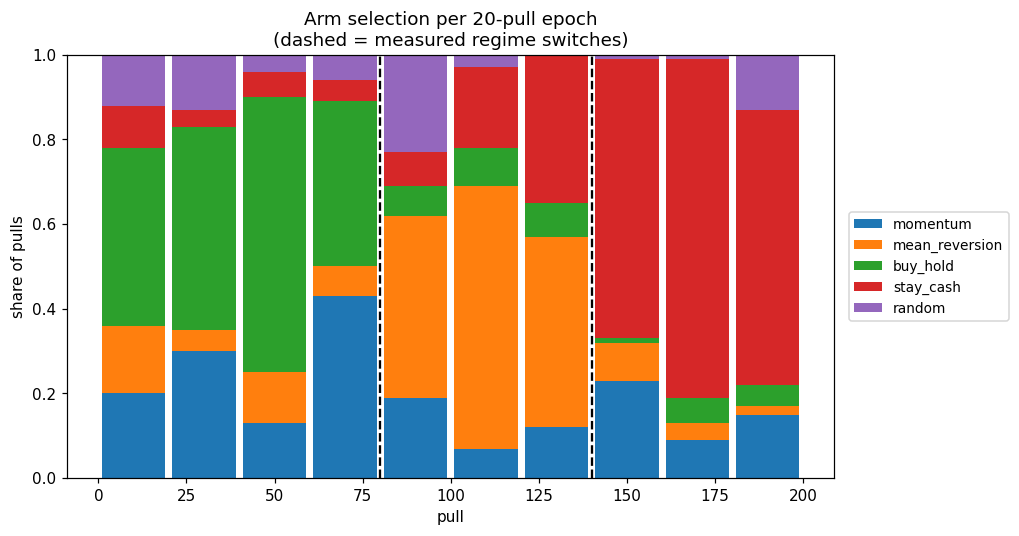

modal arm per epoch:
  pulls   0- 19  buy_hold        42%
  pulls  20- 39  buy_hold        48%
  pulls  40- 59  buy_hold        65%
  pulls  60- 79  momentum        43%
  pulls  80- 99  mean_reversion  43%
  pulls 100-119  mean_reversion  62%
  pulls 120-139  mean_reversion  45%
  pulls 140-159  stay_cash       66%
  pulls 160-179  stay_cash       80%
  pulls 180-199  stay_cash       65%


In [5]:
from IM07_agent_bandit import Agent as UCBAgent
from eval_harness import BANDIT_EVAL_SEEDS, BANDIT_N_PULLS


def bandit_trace(agent_cls, seed, **kwargs):
    agent = agent_cls(n_arms=len(STRATEGIES), **kwargs)
    env = TradingBanditEnv(total_pulls=BANDIT_N_PULLS)
    env.reset(seed=seed)
    arms = np.empty(BANDIT_N_PULLS, dtype=int)
    rew = np.empty(BANDIT_N_PULLS)
    for t in range(BANDIT_N_PULLS):
        a = agent.select_arm()
        r = env.pull(a)
        agent.update(a, r)
        arms[t], rew[t] = a, r
    return arms, rew


EPOCH = 20
counts = np.zeros((BANDIT_N_PULLS // EPOCH, len(STRATEGIES)))
for s in BANDIT_EVAL_SEEDS:
    arms, _ = bandit_trace(UCBAgent, s)
    for t, a in enumerate(arms):
        counts[t // EPOCH, a] += 1
share = counts / counts.sum(axis=1, keepdims=True)

fig, ax = plt.subplots()
bottom = np.zeros(len(share))
x = np.arange(len(share)) * EPOCH + EPOCH / 2
for a, name in enumerate(STRATEGIES):
    ax.bar(x, share[:, a], width=EPOCH * 0.9, bottom=bottom, label=name)
    bottom += share[:, a]
for b in boundaries:
    ax.axvline(b, color="k", ls="--", lw=1.5)
ax.set_xlabel("pull")
ax.set_ylabel("share of pulls")
ax.set_ylim(0, 1)
ax.set_title("Arm selection per 20-pull epoch\n(dashed = measured regime switches)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.show()

print("modal arm per epoch:")
for e in range(len(share)):
    print(f"  pulls {e * EPOCH:3d}-{e * EPOCH + EPOCH - 1:3d}  "
          f"{STRATEGIES[share[e].argmax()]:<15s} {share[e].max():.0%}")

The modal arm changes at exactly the two measured switch points.

The apparent miss around pulls 60-79 -- drifting toward `momentum` while
`buy_hold` is still best -- is not a failure. `momentum`'s gap in the bull phase
is the smallest non-zero gap in the game, so the regret cost of that confusion is
near zero. Small counts on large gaps, large counts on small gaps: precisely what
the regret decomposition prescribes.

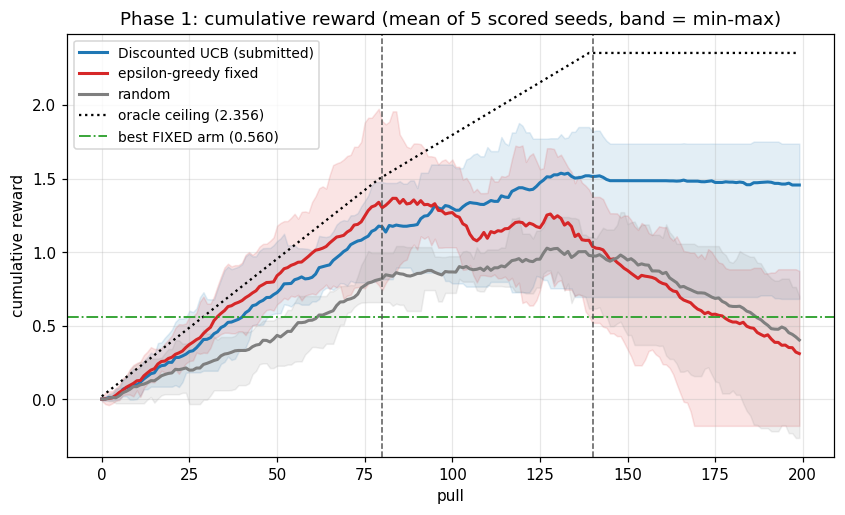

In [6]:
from baseline_agents import RandomBanditAgent, EpsilonGreedyBanditAgent

ORACLE_PER_PULL = {0: 0.0187, 1: 0.0143, 2: 0.0000}
phase_of = lambda p: 0 if p < boundaries[0] else (1 if p < boundaries[1] else 2)

fig, ax = plt.subplots()
for label, cls, colour in [("Discounted UCB (submitted)", UCBAgent, "C0"),
                           ("epsilon-greedy fixed", EpsilonGreedyBanditAgent, "C3"),
                           ("random", RandomBanditAgent, "C7")]:
    curves = np.array([np.cumsum(bandit_trace(cls, s)[1]) for s in BANDIT_EVAL_SEEDS])
    ax.plot(curves.mean(axis=0), color=colour, lw=2, label=label)
    ax.fill_between(range(BANDIT_N_PULLS), curves.min(axis=0), curves.max(axis=0),
                    color=colour, alpha=0.12)

ax.plot(np.cumsum([ORACLE_PER_PULL[phase_of(p)] for p in range(BANDIT_N_PULLS)]),
        color="k", ls=":", lw=1.5, label="oracle ceiling (2.356)")
ax.axhline(0.560, color="C2", ls="-.", lw=1.2, label="best FIXED arm (0.560)")
for b in boundaries:
    ax.axvline(b, color="0.35", ls="--", lw=1)
ax.set_xlabel("pull")
ax.set_ylabel("cumulative reward")
ax.set_title("Phase 1: cumulative reward (mean of 5 scored seeds, band = min-max)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 4. Why the exploration bonus is kept despite a lower mean

The sweep found that `c = 0` -- no exploration bonus at all, purely greedy on
discounted value estimates -- achieves the best held-out mean of every
configuration tried. It was rejected anyway. This is Lecture 6's two-doors
lock-in, observed in our own data.

In [7]:
from IM07_holdout_bandit import score_on_seeds, HOLDOUT_SEEDS

for alpha, gamma_d, c, label in [(0.15, 0.99, 0.01, "submitted (c = 0.01)"),
                                 (0.10, 1.00, 0.00, "c = 0, no bonus")]:
    ho = score_on_seeds(alpha, gamma_d, c, HOLDOUT_SEEDS)
    print(f"{label:<24} held-out mean {ho.mean():6.3f}   worst seed {ho.min():+.3f}   "
          f"runs below zero: {(ho < 0).sum()}/{len(ho)}")

submitted (c = 0.01)     held-out mean  1.302   worst seed +0.228   runs below zero: 0/40


c = 0, no bonus          held-out mean  1.442   worst seed -0.097   runs below zero: 2/40


Without a bonus, one unlucky early sample can silence an arm permanently -- there
is nothing left in the agent that would ever revisit it. That happens rarely, so
the *mean* looks excellent; when it does happen the run is destroyed. Reporting
the worst seed next to the mean is the only reason this was caught, and it is why
the submitted configuration keeps a small bonus at a slightly lower mean.

## 5. Phase 2 -- one measurement explains almost everything

In [8]:
from trading_env import TradingEnv

env = TradingEnv(episode_length=60)
rewards = []
for ep in range(30):
    env.reset(seed=ep)
    done = False
    while not done:
        _, r, done, _ = env.step(2)   # always long
        rewards.append(r)
rewards = np.array(rewards)

print(f"per-step reward : mean {rewards.mean():+.6f}   sd {rewards.std():.6f}")
print(f"signal-to-noise : 1 : {rewards.std() / abs(rewards.mean()):.0f}")
for g in (0.95, 0.99):
    horizon = 1.0 / (1.0 - g)
    print(f"gamma={g}: effective horizon {horizon:5.1f} steps, "
          f"plausible |Q| ~ {abs(rewards.mean()) * min(horizon, 60):.5f}")

per-step reward : mean -0.000403   sd 0.014172
signal-to-noise : 1 : 35
gamma=0.95: effective horizon  20.0 steps, plausible |Q| ~ 0.00807
gamma=0.99: effective horizon 100.0 steps, plausible |Q| ~ 0.02420


Signal-to-noise of roughly **1:35**. This is Lecture 4's bias/variance trade-off
in an extreme form, and it is why two lecture-derived predictions in the plan
failed:

- **gamma = 0.99 lost to gamma = 0.95.** The Lecture 2 argument -- a 60-day
  episode needs an effective horizon above 60 -- is about *bias* and silent about
  *variance*. Here a longer bootstrap horizon accumulates noise faster than it
  accumulates signal.
- **GLIE decay to eps = 0.01 lost to a floor of eps = 0.10.** Both GLIE conditions
  are *asymptotic*. 300 episodes over a 90-cell table at this noise level is
  nowhere near asymptotic, so becoming greedy early just freezes noise into the
  policy.

The last line also fixes the optimistic-initialisation scale: `q_init = 0.03` sits
just above plausible |Q|, whereas the first attempt at 0.01 was *pessimistic*. The
lecture formula `r_max/(1-gamma)` is stated for rewards on [0, 1] and must be
rescaled here, exactly like the UCB bonus constant in Phase 1.

## 6. Is Q-learning really better than SARSA?

The sweep reported Q-learning 0.0389 against SARSA 0.0357 on the graded block.
Before claiming a winner, test whether that margin is distinguishable from noise.
The harness scores 50 episodes; this runs 400 and pairs them by seed.

In [9]:
from IM07_agent_mdp import QLearningAgent, SarsaAgent
from eval_harness import (
    MDP_EPISODE_LENGTH,
    MDP_N_TRAIN_EPISODES,
    MDP_TRAIN_SEED_START,
    DRAWDOWN_PENALTY_LAMBDA,
    _max_drawdown,
    _pin_agent_randomness,
)


def train_mdp(cls, **kwargs):
    _pin_agent_randomness()
    env = TradingEnv(episode_length=MDP_EPISODE_LENGTH)
    agent = cls(TradingEnv.N_STATES, TradingEnv.N_ACTIONS, **kwargs)
    for ep in range(MDP_N_TRAIN_EPISODES):
        state = env.reset(seed=MDP_TRAIN_SEED_START + ep)
        agent.start_episode()
        done = False
        while not done:
            a = agent.act(state)
            nxt, r, done, _ = env.step(a)
            agent.update(state, a, r, nxt, done)
            state = nxt
    agent.set_eval_mode(True)
    return agent, env


def per_episode_scores(env, agent, seed_start, n):
    out = []
    for i in range(n):
        s = env.reset(seed=seed_start + i)
        done = False
        while not done:
            s, _, done, _ = env.step(agent.act(s))
        ret = env.portfolio_value - 1.0
        dd = _max_drawdown(env.episode_summary().portfolio_values)
        out.append(ret - DRAWDOWN_PENALTY_LAMBDA * dd)
    return np.array(out)


N = 400
scores = {}
for label, cls in [("Q-learning", QLearningAgent), ("SARSA", SarsaAgent)]:
    agent, env = train_mdp(cls)
    scores[label] = per_episode_scores(env, agent, 100_000, N)

q, sa = scores["Q-learning"], scores["SARSA"]
diff = q - sa
print(f"over {N} held-out episodes (the harness uses 50):")
for k, v in scores.items():
    print(f"  {k:<12} mean {v.mean():+.4f}   sd {v.std():.4f}   se {v.std() / np.sqrt(N):.4f}")
t = diff.mean() / (diff.std() / np.sqrt(N))
print(f"\npaired difference (Q - SARSA) {diff.mean():+.4f}   se {diff.std() / np.sqrt(N):.4f}")
print(f"paired t = {t:+.2f}  ->  "
      f"{'significant' if abs(t) > 1.96 else 'NOT significant at 95%'}")
print(f"\nfirst 50 episodes only: Q {q[:50].mean():+.4f}   SARSA {sa[:50].mean():+.4f}"
      f"   (this is the harness's sample size)")

over 400 held-out episodes (the harness uses 50):
  Q-learning   mean +0.0273   sd 0.0974   se 0.0049
  SARSA        mean +0.0270   sd 0.0965   se 0.0048

paired difference (Q - SARSA) +0.0003   se 0.0022
paired t = +0.13  ->  NOT significant at 95%

first 50 episodes only: Q +0.0389   SARSA +0.0396   (this is the harness's sample size)


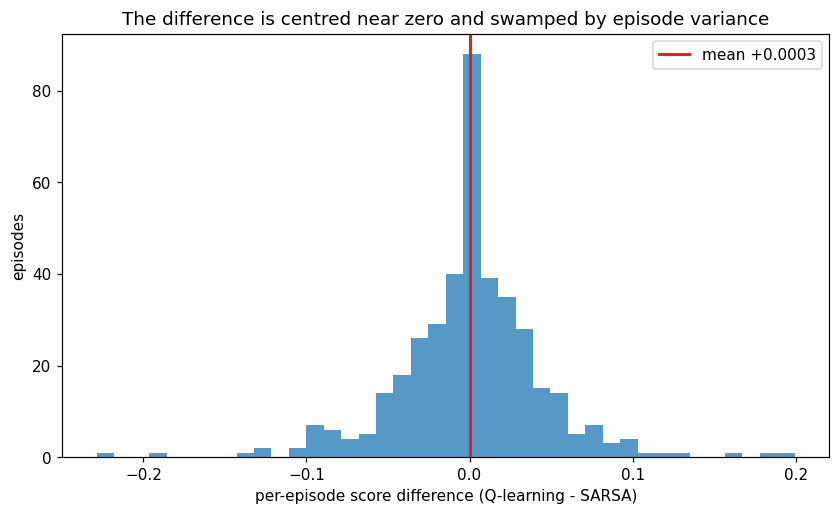

In [10]:
fig, ax = plt.subplots()
ax.hist(diff, bins=40, color="C0", alpha=0.75)
ax.axvline(0, color="k", lw=1)
ax.axvline(diff.mean(), color="C3", lw=2, label=f"mean {diff.mean():+.4f}")
ax.set_xlabel("per-episode score difference (Q-learning - SARSA)")
ax.set_ylabel("episodes")
ax.set_title("The difference is centred near zero and swamped by episode variance")
ax.legend()
plt.show()

**Retraction.** The two algorithms are statistically indistinguishable on
risk-adjusted score. The per-episode standard deviation is roughly 0.097, more
than twice the mean score itself, so 50 episodes gives a standard error around
twenty times the true difference. The 0.0389-versus-0.0357 gap is sampling noise,
and the report's section 4.4 now says so.

What does survive is the *mechanism*: SARSA reliably produces the lower-drawdown
policy, as Lecture 5's cliff-walking example predicts for an on-policy learner.
The drawdown difference is a property of the learned policy; the score difference
is not. Q-learning is submitted because it is simpler to justify, not because it
was shown to be better.

## 7. Final submitted scores

In [11]:
import importlib.util
import time


def load_agent(path):
    spec = importlib.util.spec_from_file_location("submitted", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.Agent


t0 = time.time()
r1 = run_bandit_eval(load_agent("IM07_agent_bandit.py"))
t1 = time.time() - t0

t0 = time.time()
r2 = run_mdp_eval(load_agent("IM07_agent_mdp.py"))
t2 = time.time() - t0

print(f"Phase 1  score {r1['score']:.4f}   [{t1:.1f}s of 30s budget]")
print(f"         {r1['score'] / 2.356:.1%} of oracle, "
      f"{r1['score'] / 0.560:.2f}x the best fixed arm")
print(f"         per-seed {[round(float(x), 3) for x in r1['per_seed_rewards']]}")
print()
print(f"Phase 2  score {r2['score']:.4f}   [{t2:.1f}s of 90s budget]")
print(f"         {r2['score'] / 0.0279:.2f}x the untuned baseline")
print(f"         return {r2['mean_return']:.4f}   drawdown {r2['mean_max_drawdown']:.4f}")

Phase 1  score 1.4559   [0.1s of 30s budget]
         61.8% of oracle, 2.60x the best fixed arm
         per-seed [1.732, 1.499, 1.63, 1.737, 0.681]

Phase 2  score 0.0389   [2.2s of 90s budget]
         1.39x the untuned baseline
         return 0.0565   drawdown 0.0352
